# Análise dos Microdados do Enamed 2025


# 2. Membros

| Nome | Matrícula |
|------|-----------|
| Marco Fabian Alves Lopes Freire | 2025070853 |
| Rafael do Valle Sollino | 2025050652 |
| Letícia Ribeiro Vono | 2025087661 |
| Thales Mendonça Pereira | 2025122424 |


# 3. Descrição dos dados

## Fonte e domínio

- **URL:** Portal de Dados Abertos do INEP — Microdados do Enamed
  (`https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enamed`)
- **Domínio:** avaliação educacional na área da saúde. O Enamed substitui o
  Enade para os cursos de Medicina e funciona também como porta de entrada
  para a residência médica. Cada registro descreve um **estudante** que prestou
  a prova, com seu desempenho, o **curso/IES** de origem, a **localização**
  (município/UF) e os **vetores de respostas** (gabarito, acertos e marcações),
  além dos **parâmetros psicométricos (TRI)** de cada item da prova.

## Como os dados foram processados (ETL)

O processamento segue três etapas, implementadas em `etl/`:

1. **Extract (`etl/extract.py`)** — descompacta o `.zip` do INEP, lê os CSVs
   (separados por `;`, encoding `latin-1`) e valida colunas/contagens.
2. **Transform (`etl/transform.py`)** — decodifica os códigos categóricos
   usando o dicionário do Manual do Usuário (ex.: `TP_SEXO`, `CO_CATEGAD`,
   `REGIAO`), trata valores ausentes, separa a tabela única achatada do INEP
   nas **11 entidades normalizadas** do nosso modelo e gera as tabelas-ponte
   das relações M:N (`Composicao`, `Resposta`).
3. **Load (`etl/load.py`)** — cria o `data/processed/enamed.db` a partir do
   DDL (`sql/01_create_tables.sql`) e popula todas as tabelas.

A normalização parte da tabela achatada do INEP (1 linha por estudante, com
município, IES, notas e vetores repetidos) e a decompõe até a 3FN, eliminando
redundância: dados de `UF`, `Municipio`, `IES`, `Curso`, `Caderno` e
`Item_prova` passam a ser referenciados por chave estrangeira em vez de
repetidos a cada estudante.

> O notebook abaixo conecta ao banco já populado. Caso os microdados reais não
> estejam disponíveis, rode `python etl/seed.py` para gerar um banco
> **fictício** (dados inventados) e reproduzir todas as consultas.

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# localiza a raiz do projeto (pasta que contém sql/01_create_tables.sql)
# assim o notebook roda de qualquer lugar do repositório
root = os.getcwd()
while not os.path.exists(os.path.join(root, "sql", "01_create_tables.sql")):
    parent = os.path.dirname(root)
    if parent == root:
        break
    root = parent
os.chdir(root)

DB = "data/processed/enamed.db"

# fallback: se o banco não existir, gera o banco fictício de demonstração
if not os.path.exists(DB):
    print("Banco não encontrado — gerando banco fictício de demonstração...")
    os.system("python etl/seed.py")

con = sqlite3.connect(DB)

def q(sql):
    # executa um SELECT e devolve um DataFrame
    return pd.read_sql_query(sql, con)

# conferência rápida do povoamento
tabelas = ["UF", "Municipio", "IES", "Curso", "Caderno", "Item_prova",
           "Notas", "Vetores", "Estudante", "Composicao", "Resposta"]
pd.DataFrame(
    [(t, q(f"SELECT COUNT(*) AS n FROM {t}").n[0]) for t in tabelas],
    columns=["Tabela", "Linhas"]
)

,Tabela,Linhas
0,UF,9
1,Municipio,11
2,IES,5
3,Curso,15
4,Caderno,2
5,Item_prova,5
6,Notas,300
7,Vetores,300
8,Estudante,300
9,Composicao,10


# 4. Diagrama ER

![Diagrama ER](docs/diagramas/er.png)

> Exporte `docs/diagramas/ModeloEREnamed.drawio` como PNG no draw.io
> (*File → Export as → PNG*) salvando em `docs/diagramas/er.png`.

# 5. Diagrama relacional

![Diagrama relacional](docs/diagramas/relacional.png)

> Exporte `docs/diagramas/modelorelacionalEnamed.drawio` como PNG salvando em
> `docs/diagramas/relacional.png`.

# 6. Consultas

Cada consulta apresenta: uma **explicação textual**, a expressão em **álgebra
relacional (AR)**, o comando **SQL** e o **resultado**. Onde ajuda na leitura,
incluímos um gráfico.

## 6.1 Duas consultas envolvendo seleção e projeção

### 6.1.1 Consulta 1

Lista o código e a idade dos estudantes com **mais de 25 anos**. Seleção e
projeção sobre uma única relação.

**AR:** $\pi_{\text{CO\_ESTUDANTE},\ \text{NU\_IDADE}}\big(\sigma_{\text{NU\_IDADE} > 25}(\text{Estudante})\big)$

In [2]:
df = q('''
SELECT CO_ESTUDANTE, NU_IDADE
FROM Estudante
WHERE NU_IDADE > 25;
''')
print(f"{len(df)} estudantes com mais de 25 anos")
df.head()

251 estudantes com mais de 25 anos


,CO_ESTUDANTE,NU_IDADE
0,1,38
1,2,26
2,3,28
3,4,36
4,5,30


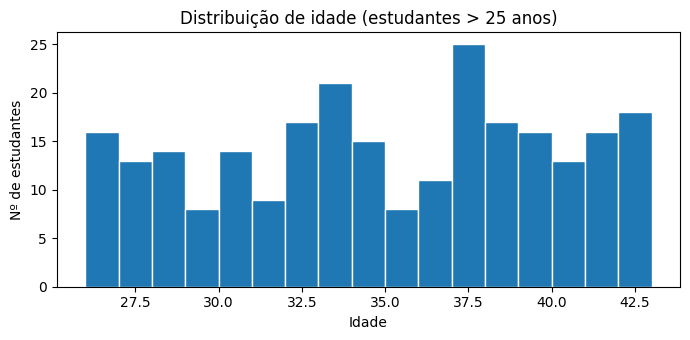

In [3]:
plt.figure(figsize=(7, 3.5))
plt.hist(df["NU_IDADE"], bins=range(df.NU_IDADE.min(), df.NU_IDADE.max() + 2),
         edgecolor="white")
plt.title("Distribuição de idade (estudantes > 25 anos)")
plt.xlabel("Idade"); plt.ylabel("Nº de estudantes")
plt.tight_layout(); plt.show()

### 6.1.2 Consulta 2

Lista o código e a quantidade de vagas dos cursos **presenciais com pelo menos
80 vagas**. Seleção com duas condições e projeção sobre uma única relação.

**AR:** $\pi_{\text{CO\_CURSO},\ \text{QTD\_VAGAS}}\big(\sigma_{\text{MODALIDADE}=\text{'Presencial'}\ \wedge\ \text{QTD\_VAGAS} \ge 80}(\text{Curso})\big)$

In [4]:
q('''
SELECT CO_CURSO, QTD_VAGAS
FROM Curso
WHERE MODALIDADE = 'Presencial'
  AND QTD_VAGAS >= 80
ORDER BY QTD_VAGAS DESC;
''')

,CO_CURSO,QTD_VAGAS
0,300,120
1,500,120
2,1300,120
3,1200,100
4,800,80
5,1000,80
6,1500,80


## 6.2 Três consultas envolvendo junção de duas relações

### 6.2.1 Consulta 3

Nome do município junto com o nome e a região da UF, restrito à região
**Sudeste**. Junção de `Municipio` e `UF`.

**AR:** $\pi_{\text{M.NOME},\ \text{U.NOME},\ \text{U.REGIAO}}\big(\sigma_{\text{U.REGIAO}=\text{'Sudeste'}}(\text{Municipio} \bowtie \text{UF})\big)$

In [5]:
q('''
SELECT M.NOME AS MUNICIPIO, U.NOME AS UF, U.REGIAO
FROM Municipio M
JOIN UF U ON M.CO_UF = U.CO_UF
WHERE U.REGIAO = 'Sudeste';
''')

,MUNICIPIO,UF,REGIAO
0,Belo Horizonte,Minas Gerais,Sudeste
1,Uberlândia,Minas Gerais,Sudeste
2,Rio de Janeiro,Rio de Janeiro,Sudeste
3,Ribeirão Preto,São Paulo,Sudeste
4,São Paulo,São Paulo,Sudeste


### 6.2.2 Consulta 4

Estudantes com **proficiência (TRI) acima de 600**, com sua respectiva nota.
Junção de `Estudante` e `Notas` (relação 1:1).

**AR:** $\pi_{\text{E.CO\_ESTUDANTE},\ \text{N.PROFICIENCIA}}\big(\sigma_{\text{N.PROFICIENCIA} > 600}(\text{Estudante} \bowtie \text{Notas})\big)$

In [6]:
df = q('''
SELECT E.CO_ESTUDANTE, N.PROFICIENCIA
FROM Estudante E
JOIN Notas N ON E.CO_NOTA = N.CO_NOTA
WHERE N.PROFICIENCIA > 600
ORDER BY N.PROFICIENCIA DESC;
''')
print(f"{len(df)} estudantes com proficiência > 600")
df.head()

118 estudantes com proficiência > 600


,CO_ESTUDANTE,PROFICIENCIA
0,197,799.99
1,30,798.05
2,96,795.02
3,184,793.27
4,202,792.22


### 6.2.3 Consulta 5

Para cada curso, o nome do município onde funciona e o IDH desse município,
ordenado por IDH. Junção de `Curso` e `Municipio`.

**AR:** $\pi_{\text{C.CO\_CURSO},\ \text{M.NOME},\ \text{M.IDH}}(\text{Curso} \bowtie \text{Municipio})$

In [7]:
q('''
SELECT C.CO_CURSO, M.NOME AS MUNICIPIO, M.IDH
FROM Curso C
JOIN Municipio M ON C.CO_MUNICIPIO = M.CO_MUNICIPIO
ORDER BY M.IDH DESC;
''')

,CO_CURSO,MUNICIPIO,IDH
0,600,Brasília,0.824
1,1000,Brasília,0.824
2,1300,Brasília,0.824
3,300,Belo Horizonte,0.810
4,700,Porto Alegre,0.805
5,900,Porto Alegre,0.805
6,100,Ribeirão Preto,0.800
7,400,Ribeirão Preto,0.800
8,800,Ribeirão Preto,0.800
9,1500,Ribeirão Preto,0.800


## 6.3 Três consultas envolvendo junção de três ou mais relações

### 6.3.1 Consulta 6

Para cada estudante, a modalidade do seu curso e a categoria administrativa da
IES. Junção de `Estudante`, `Curso` e `IES`.

**AR:** $\pi_{\text{E.CO\_ESTUDANTE},\ \text{C.MODALIDADE},\ \text{I.CO\_CATEGAD}}\big((\text{Estudante} \bowtie \text{Curso}) \bowtie \text{IES}\big)$

In [8]:
q('''
SELECT E.CO_ESTUDANTE, C.MODALIDADE, I.CO_CATEGAD
FROM Estudante E
JOIN Curso C ON E.CO_CURSO = C.CO_CURSO
JOIN IES I   ON C.CO_IES = I.CO_IES
LIMIT 20;
''')

,CO_ESTUDANTE,MODALIDADE,CO_CATEGAD
0,2,Presencial,1
1,6,Presencial,1
2,10,Presencial,1
3,37,Presencial,1
4,69,Presencial,1
5,91,Presencial,1
6,99,Presencial,1
7,110,Presencial,1
8,152,Presencial,1
9,168,Presencial,1


### 6.3.2 Consulta 7

Nota geral (`NT_GER`) de cada estudante junto com a **região** da UF onde está
seu curso. Encadeia `Estudante` → `Notas`, `Curso`, `Municipio` e `UF`
(5 relações).

**AR:** $\pi_{\text{E.CO\_ESTUDANTE},\ \text{U.REGIAO},\ \text{N.NT\_GER}}\big(\text{Estudante} \bowtie \text{Notas} \bowtie \text{Curso} \bowtie \text{Municipio} \bowtie \text{UF}\big)$

In [9]:
df = q('''
SELECT E.CO_ESTUDANTE, U.REGIAO, N.NT_GER
FROM Estudante E
JOIN Notas N     ON E.CO_NOTA = N.CO_NOTA
JOIN Curso C     ON E.CO_CURSO = C.CO_CURSO
JOIN Municipio M ON C.CO_MUNICIPIO = M.CO_MUNICIPIO
JOIN UF U        ON M.CO_UF = U.CO_UF;
''')
df.head()

,CO_ESTUDANTE,REGIAO,NT_GER
0,1,Norte,55.73
1,2,Sudeste,77.25
2,3,Sudeste,89.87
3,4,Nordeste,79.60
4,5,Sul,88.55


/tmp/ipykernel_658/3244331897.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=ordem, vert=True)


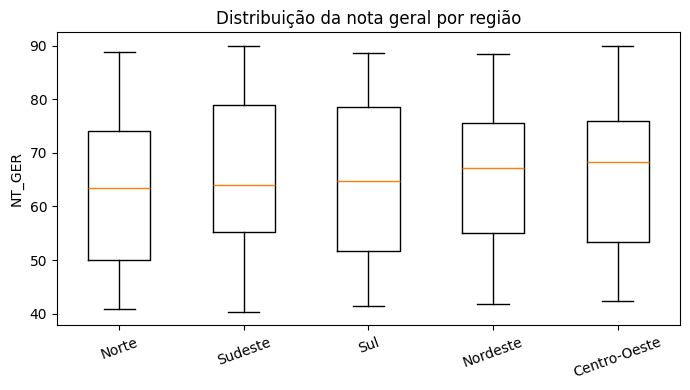

In [10]:
ordem = df.groupby("REGIAO")["NT_GER"].median().sort_values().index
dados = [df.loc[df.REGIAO == r, "NT_GER"] for r in ordem]
plt.figure(figsize=(7, 4))
plt.boxplot(dados, labels=ordem, vert=True)
plt.title("Distribuição da nota geral por região")
plt.ylabel("NT_GER"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### 6.3.3 Consulta 8

Itens que compõem cada caderno, com a posição e o parâmetro de dificuldade
(TRI) do item. Junção de `Caderno`, `Composicao` e `Item_prova`.

**AR:** $\pi_{\text{CD.CO\_CADERNO},\ \text{I.CO\_ITEM},\ \text{CO.POSICAO},\ \text{I.PARAMETRO\_B}}\big(\text{Caderno} \bowtie \text{Composicao} \bowtie \text{Item\_prova}\big)$

In [11]:
q('''
SELECT CD.CO_CADERNO, I.CO_ITEM, CO.POSICAO, I.PARAMETRO_B
FROM Caderno CD
JOIN Composicao CO ON CD.CO_CADERNO = CO.CO_CADERNO
JOIN Item_prova I  ON CO.CO_ITEM = I.CO_ITEM
ORDER BY CD.CO_CADERNO, CO.POSICAO;
''')

,CO_CADERNO,CO_ITEM,POSICAO,PARAMETRO_B
0,1,1,1,0.67
1,1,2,2,0.87
2,1,3,3,-0.67
3,1,4,4,-0.56
4,1,5,5,-0.94
5,2,1,1,0.67
6,2,2,2,0.87
7,2,3,3,-0.67
8,2,4,4,-0.56
9,2,5,5,-0.94


## 6.4 Duas consultas envolvendo agregação sobre junção de duas ou mais relações

### 6.4.1 Consulta 9

Número de estudantes por município, do maior para o menor. Agregação
(`COUNT`) sobre a junção de `Municipio`, `Curso` e `Estudante`.

**AR:** $_{\text{M.NOME}}\mathcal{G}_{\text{count}(\text{E.CO\_ESTUDANTE})}\big(\text{Municipio} \bowtie \text{Curso} \bowtie \text{Estudante}\big)$

In [12]:
df = q('''
SELECT M.NOME AS MUNICIPIO, COUNT(E.CO_ESTUDANTE) AS TOTAL_ESTUDANTES
FROM Municipio M
JOIN Curso C     ON M.CO_MUNICIPIO = C.CO_MUNICIPIO
JOIN Estudante E ON C.CO_CURSO = E.CO_CURSO
GROUP BY M.NOME
ORDER BY TOTAL_ESTUDANTES DESC;
''')
df

,MUNICIPIO,TOTAL_ESTUDANTES
0,Ribeirão Preto,76
1,Manaus,67
2,Brasília,53
3,Fortaleza,45
4,Porto Alegre,39
5,Belo Horizonte,20


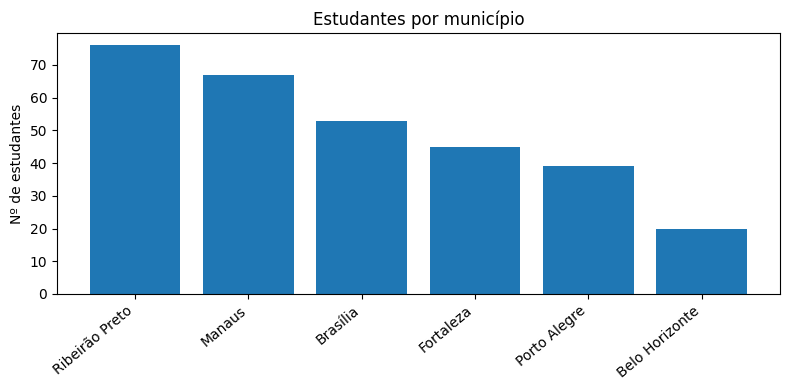

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(df["MUNICIPIO"], df["TOTAL_ESTUDANTES"])
plt.title("Estudantes por município")
plt.ylabel("Nº de estudantes"); plt.xticks(rotation=40, ha="right")
plt.tight_layout(); plt.show()

### 6.4.2 Consulta 10

Por região: total de estudantes e **proficiência média**. Agregação
(`COUNT`, `AVG`) sobre a junção de `Estudante`, `Notas`, `Curso`,
`Municipio` e `UF`.

**AR:** $_{\text{U.REGIAO}}\mathcal{G}_{\text{count}(\text{E.CO\_ESTUDANTE}),\ \text{avg}(\text{N.PROFICIENCIA})}\big(\text{Estudante} \bowtie \text{Notas} \bowtie \text{Curso} \bowtie \text{Municipio} \bowtie \text{UF}\big)$

In [14]:
df = q('''
SELECT U.REGIAO,
       COUNT(E.CO_ESTUDANTE)          AS TOTAL,
       ROUND(AVG(N.PROFICIENCIA), 1)  AS PROF_MEDIA
FROM Estudante E
JOIN Notas N     ON E.CO_NOTA = N.CO_NOTA
JOIN Curso C     ON E.CO_CURSO = C.CO_CURSO
JOIN Municipio M ON C.CO_MUNICIPIO = M.CO_MUNICIPIO
JOIN UF U        ON M.CO_UF = U.CO_UF
GROUP BY U.REGIAO
ORDER BY PROF_MEDIA DESC;
''')
df

,REGIAO,TOTAL,PROF_MEDIA
0,Nordeste,45,579.9
1,Sul,39,569.5
2,Norte,67,566.5
3,Sudeste,96,543.0
4,Centro-Oeste,53,542.2


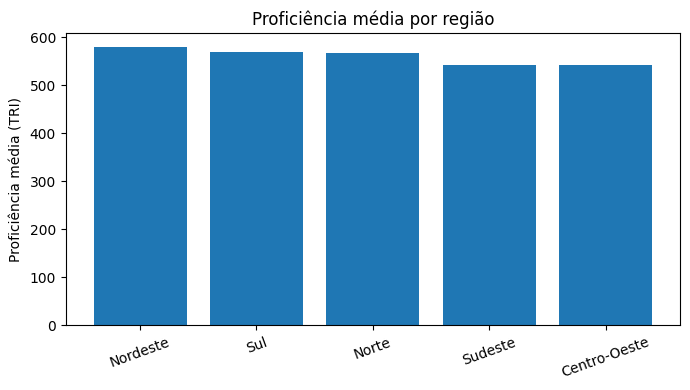

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(df["REGIAO"], df["PROF_MEDIA"])
plt.title("Proficiência média por região")
plt.ylabel("Proficiência média (TRI)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

# 7. Autoavaliação dos membros

| Membro | Contribuição |
|--------|--------------|
| Marco Fabian Alves Lopes Freire | Relatório inicial, 5 Consultas inicias, Deploy do Streamlit com Qr Code e Repo Github |
| Rafael do Valle Sollino | App Streamlit, 5 Consultas e Relatório Final |
| Letícia Ribeiro Vono | |
| Thales Mendonça Pereira | |


In [16]:
con.close()